# Modelo de Impacto — Estágio 2 (Aprender o efeito da chegada do data center)

Implementa o Estágio 2 descrito em [`proposta_projeto.md`](../proposta_projeto.md): a partir do
porte do data center e do contexto/tendência pré-obra da região (extraídos no Estágio 1, já
consolidados em `consolidado_impacto_modelo.csv`), aprender **o quanto a chegada do data center
muda cada variável, além do que já era esperado pela tendência regional** — medido nos horizontes
0 (ano de abertura), +1 e +2, sempre comparado com o ano anterior à abertura.

Pipeline desta notebook:
1. Carrega o painel consolidado.
2. Recalcula `delta_*` (variação vs. ano-base pré-obra) para cada área.
3. Extrai nível e tendência pré-obra por área (features fixas, item 5 do guia de estrutura).
4. Monta o alvo do modelo: **efeito líquido** (`delta_tratamento - delta_controle`) por par e
   horizonte (0, +1, +2).
5. Treina um Random Forest raso por variável de interesse, valida com **Leave-One-DC-Out**
   (proposta, item 6) e compara com uma baseline ingênua (prever a média).
6. Reporta importância das features.
7. Disponibiliza uma função para prever o impacto esperado de um data center hipotético.

**Limitação conhecida (proposta, item 7):** com apenas 15 pares tratamento/controle disponíveis
hoje, a amostra é pequena para qualquer modelo de ML — por isso o modelo é raso
(`max_depth=3`) e a validação Leave-One-DC-Out serve para medir honestamente se o modelo generaliza
melhor que simplesmente prever a média, não para produzir uma métrica de "produção".

## 1. Configuração e carga dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
df = pd.read_csv('../data/02_silver/consolidado_impacto_modelo.csv')
df = df.sort_values(["site_id", "ano_relativo_ao_inicio_obra"])

VARS_SATELITE = [
    "prop_vegetacao_densa", "prop_vegetacao_rala",
    "prop_solo_exposto_obras", "prop_construida_urbana", "prop_agua",
]
VARS_CLIMA = ["lst_media_celsius"]
VARS_SOCIO = ["populacao", "emprego_formal_total", "pib_mil_reais", "numero_empresas"]
VARS_ALVO = VARS_SATELITE + VARS_CLIMA + VARS_SOCIO
HORIZONTES_ALVO = [0, 1, 2]  # conforme a proposta: abertura, +1 ano, +2 anos

print(df.shape)


(204, 51)


## 2. Delta por área (variação vs. ano-base pré-obra)

Ano-base = horizonte pré-obra mais próximo de 0 (idealmente -1). Importante: o filtro é
`ano_relativo_ao_inicio_obra < 0` (estritamente antes da obra) — horizonte `0` já é fase
"durante", usar `<= 0` faria o ano-base cair em cima do próprio horizonte 0.

In [3]:
pre_mask = df["ano_relativo_ao_inicio_obra"] < 0
pre = df[pre_mask]
idx_baseline = pre.groupby("site_id")["ano_relativo_ao_inicio_obra"].idxmax()

sites_sem_pre = set(df["site_id"]) - set(pre["site_id"])
if sites_sem_pre:
    idx_fallback = (
        df[df["site_id"].isin(sites_sem_pre)]
        .groupby("site_id")["ano_relativo_ao_inicio_obra"]
        .idxmin()
    )
    idx_baseline = pd.concat([idx_baseline, idx_fallback])

baseline_map = df.loc[idx_baseline].set_index("site_id")[VARS_ALVO]

for col in VARS_ALVO:
    df[f"delta_{col}"] = df.apply(
        lambda row: row[col] - baseline_map.loc[row["site_id"], col]
        if row["site_id"] in baseline_map.index else np.nan,
        axis=1,
    )

print(f"Ano-base calculado para {len(baseline_map)} áreas")


Ano-base calculado para 30 áreas


## 3. Nível e tendência pré-obra (features fixas por área)

Para cada área e cada variável de satélite/LST/socioeconômica: `nivel_pre` (valor no ano-base) e
`tendencia_pre` (inclinação da reta ajustada nos anos pré-obra) — item 5 do guia de estrutura de
dados. Essas colunas não mudam entre horizontes da mesma área; descrevem "como a região já estava
se comportando antes do data center chegar".

In [4]:
def calcula_tendencia(serie_horizontes, serie_valores):
    if len(serie_horizontes) < 2:
        return np.nan
    coef = np.polyfit(serie_horizontes, serie_valores, deg=1)
    return coef[0]  # inclinação da reta

registros_tendencia = []
for site_id, g in df.groupby("site_id"):
    g_pre = g[g["ano_relativo_ao_inicio_obra"] < 0].sort_values("ano_relativo_ao_inicio_obra")
    linha = {"site_id": site_id}
    for var in VARS_ALVO:
        linha[f"nivel_pre_{var}"] = baseline_map.loc[site_id, var] if site_id in baseline_map.index else np.nan
        linha[f"tendencia_pre_{var}"] = calcula_tendencia(
            g_pre["ano_relativo_ao_inicio_obra"].values, g_pre[var].values
        )
    registros_tendencia.append(linha)

features_tendencia = pd.DataFrame(registros_tendencia).set_index("site_id")
features_tendencia.head()


,nivel_pre_prop_vegetacao_densa,tendencia_pre_prop_vegetacao_densa,nivel_pre_prop_vegetacao_rala,tendencia_pre_prop_vegetacao_rala,nivel_pre_prop_solo_exposto_obras,tendencia_pre_prop_solo_exposto_obras,nivel_pre_prop_construida_urbana,tendencia_pre_prop_construida_urbana,nivel_pre_prop_agua,tendencia_pre_prop_agua,nivel_pre_lst_media_celsius,tendencia_pre_lst_media_celsius,nivel_pre_populacao,tendencia_pre_populacao,nivel_pre_emprego_formal_total,tendencia_pre_emprego_formal_total,nivel_pre_pib_mil_reais,tendencia_pre_pib_mil_reais,nivel_pre_numero_empresas,tendencia_pre_numero_empresas
site_id,,,,,,,,,,,,,,,,,,,,
angonap-fortaleza,0.0535,-0.0026,0.0963,0.0012,0.0226,-0.0015,0.2900,0.0034,0.5376,-0.0005,31.8431,0.1474,2609716.0000,NaN,764914.0000,-30137.5000,60088001.0000,1985678.5000,59046.0000,-876.5000
ascenty-hortolandia,0.0595,-0.0146,0.4003,-0.0075,0.0119,0.0003,0.5254,0.0219,0.0029,-0.0002,30.9936,0.0841,222186.0000,NaN,45683.0000,601.0000,12411319.0000,700417.5000,4340.0000,-160.0000
ascenty-jundiai,0.2752,-0.0171,0.4531,0.0219,0.0195,-0.0015,0.2471,-0.0029,0.0052,-0.0003,27.1242,-0.0983,414810.0000,4535.0000,164279.0000,-622.5000,43630306.0000,1656645.0000,17788.0000,344.5000
ascenty-maracanau,0.1756,NaN,0.2693,NaN,0.0119,NaN,0.5240,NaN,0.0192,NaN,33.9145,NaN,NaN,NaN,56744.0000,NaN,6291122.0000,NaN,3760.0000,NaN
ascenty-osasco,0.2243,0.0123,0.1513,-0.0007,0.0066,-0.0004,0.6088,-0.0115,0.0090,0.0003,29.4147,0.3238,698418.0000,266.0000,161102.0000,2244.5000,81908401.0000,1990679.0000,18330.0000,1098.5000


## 4. Features estáticas por área (porte do data center + contexto regional)

Porte: capacidade construída (MW), tier, nº de prédios. Contexto: bioma, região, distância entre
tratamento e controle. Essas são as variáveis que, junto com o nível/tendência pré-obra, o modelo
usa para prever o efeito — nenhuma delas depende do horizonte.

In [5]:
COLS_PORTE = ["mw_construido_total", "tier", "tier_projetado_max",
              "n_predios_no_campus", "whitespace_construido_sqm_total",
              "n_predios_datacentermap"]
COLS_CONTEXTO_NUM = ["dist_tratamento_controle_km"]
COLS_CONTEXTO_CAT = ["bioma", "regiao"]

primeira_linha_por_site = df.groupby("site_id").first()
features_estaticas = primeira_linha_por_site[COLS_PORTE + COLS_CONTEXTO_NUM + COLS_CONTEXTO_CAT].copy()
for c in COLS_CONTEXTO_CAT:
    features_estaticas[c] = features_estaticas[c].fillna("desconhecido")

features_site = features_estaticas.join(features_tendencia)
print(f"features_site: {features_site.shape[0]} áreas x {features_site.shape[1]} features")
features_site.head()


features_site: 30 áreas x 29 features


,mw_construido_total,tier,tier_projetado_max,n_predios_no_campus,whitespace_construido_sqm_total,n_predios_datacentermap,dist_tratamento_controle_km,bioma,regiao,nivel_pre_prop_vegetacao_densa,...,nivel_pre_lst_media_celsius,tendencia_pre_lst_media_celsius,nivel_pre_populacao,tendencia_pre_populacao,nivel_pre_emprego_formal_total,tendencia_pre_emprego_formal_total,nivel_pre_pib_mil_reais,tendencia_pre_pib_mil_reais,nivel_pre_numero_empresas,tendencia_pre_numero_empresas
site_id,,,,,,,,,,,,,,,,,,,,,
angonap-fortaleza,NaN,1.0000,NaN,0,NaN,NaN,16,Caatinga,Nordeste,0.0535,...,31.8431,0.1474,2609716.0000,NaN,764914.0000,-30137.5000,60088001.0000,1985678.5000,59046.0000,-876.5000
ascenty-hortolandia,43.0000,1.0000,3.0000,4,29969.0000,4.0000,16,Mata Atlântica,Sudeste,0.0595,...,30.9936,0.0841,222186.0000,NaN,45683.0000,601.0000,12411319.0000,700417.5000,4340.0000,-160.0000
ascenty-jundiai,13.0000,2.0000,3.0000,1,8993.0000,1.0000,24,Mata Atlântica,Sudeste,0.2752,...,27.1242,-0.0983,414810.0000,4535.0000,164279.0000,-622.5000,43630306.0000,1656645.0000,17788.0000,344.5000
ascenty-maracanau,NaN,1.0000,NaN,0,NaN,NaN,36,Caatinga,Nordeste,0.1756,...,33.9145,NaN,NaN,NaN,56744.0000,NaN,6291122.0000,NaN,3760.0000,NaN
ascenty-osasco,13.0000,1.0000,3.0000,2,11492.0000,2.0000,16,Mata Atlântica,Sudeste,0.2243,...,29.4147,0.3238,698418.0000,266.0000,161102.0000,2244.5000,81908401.0000,1990679.0000,18330.0000,1098.5000


## 5. Efeito líquido por par e horizonte (alvo do modelo)

`efeito_liquido = delta_tratamento - delta_controle`, calculado só nos horizontes 0, +1 e +2 (os
3 marcos definidos na proposta). É o alvo (`y`) que o modelo aprende a prever — a diferença entre
"o que já vinha acontecendo" (capturado pelo controle) e "o que mudou a mais" com o data center.

In [6]:
pares = df["pareado_com"].dropna().unique()
registros = []
for par in pares:
    grupo = df[df["pareado_com"] == par]
    trat = grupo[grupo["tipo"] == "tratamento"].set_index("ano_relativo_ao_inicio_obra")
    ctrl = grupo[grupo["tipo"] == "controle"].set_index("ano_relativo_ao_inicio_obra")
    if trat.empty:
        continue
    site_tratado = trat["site_id"].iloc[0]
    horizontes_comuns = trat.index.intersection(ctrl.index)
    for h in HORIZONTES_ALVO:
        if h not in horizontes_comuns:
            continue
        linha = {"site_id": site_tratado, "horizonte": h}
        for var in VARS_ALVO:
            dcol = f"delta_{var}"
            linha[f"efeito_liquido_{var}"] = trat.loc[h, dcol] - ctrl.loc[h, dcol]
        registros.append(linha)

alvo_df = pd.DataFrame(registros)
print(f"{alvo_df.shape[0]} linhas (áreas tratadas x horizontes 0/1/2 disponíveis)")
alvo_df.head()


45 linhas (áreas tratadas x horizontes 0/1/2 disponíveis)


,site_id,horizonte,efeito_liquido_prop_vegetacao_densa,efeito_liquido_prop_vegetacao_rala,efeito_liquido_prop_solo_exposto_obras,efeito_liquido_prop_construida_urbana,efeito_liquido_prop_agua,efeito_liquido_lst_media_celsius,efeito_liquido_populacao,efeito_liquido_emprego_formal_total,efeito_liquido_pib_mil_reais,efeito_liquido_numero_empresas
0,angonap-fortaleza,0,-0.0088,0.0119,0.0008,-0.0027,-0.0012,0.3478,13707.0000,-10195.0000,1085626.0000,-588.0000
1,angonap-fortaleza,1,-0.0210,0.0095,-0.0015,0.0122,0.0007,0.0723,27713.0000,-1734.0000,6667580.0000,-1783.0000
2,angonap-fortaleza,2,-0.0353,0.0116,-0.0047,0.0274,0.0009,0.4558,56390.0000,-7918.0000,5841341.0000,1882.0000
3,ascenty-hortolandia,0,-0.0039,-0.0033,-0.0002,0.0077,-0.0003,0.0736,-6498.0000,-1686.0000,-2175387.0000,-363.0000
4,ascenty-hortolandia,1,-0.0151,0.0220,0.0002,-0.0065,-0.0006,0.0094,-12979.0000,1343.0000,-5040659.0000,-4106.0000


In [7]:
# Tabela de treino final: features estáticas + alvo, uma linha por (site, horizonte)
treino = alvo_df.merge(features_site, left_on="site_id", right_index=True, how="left")
print(f"treino: {treino.shape}")
treino[["site_id", "horizonte"]]


treino: (45, 41)


,site_id,horizonte
0,angonap-fortaleza,0
1,angonap-fortaleza,1
2,angonap-fortaleza,2
3,ascenty-hortolandia,0
4,ascenty-hortolandia,1
5,ascenty-hortolandia,2
6,ascenty-jundiai,0
7,ascenty-jundiai,1
8,ascenty-jundiai,2
9,ascenty-maracanau,0


## 6. Pipeline do modelo (Random Forest raso) e validação Leave-One-DC-Out

Conforme a proposta (item 7), o modelo é intencionalmente simples (`max_depth=3`) dado o tamanho
pequeno da amostra. A validação segue o item 6 da proposta / item 9 do guia: remove **a área
inteira** (todos os horizontes dela) do treino a cada rodada — nunca linhas isoladas — e compara o
erro do modelo com uma baseline ingênua que só prevê a média do treino, sem usar nenhuma feature.
Essa comparação é o que diz se o modelo está de fato aprendendo algo além da média geral.

In [8]:
FEATURES_NUM = COLS_PORTE + COLS_CONTEXTO_NUM + list(features_tendencia.columns) + ["horizonte"]
FEATURES_CAT = COLS_CONTEXTO_CAT

preprocessador = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), FEATURES_NUM),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), FEATURES_CAT),
])

def monta_modelo():
    return Pipeline([
        ("preprocessa", preprocessador),
        ("modelo", RandomForestRegressor(
            n_estimators=200, max_depth=3, min_samples_leaf=2,
            random_state=42,
        )),
    ])

VARS_MODELO = ["prop_vegetacao_densa", "prop_construida_urbana", "lst_media_celsius"]


In [9]:
resultados_validacao = []
for var in VARS_MODELO:
    target_col = f"efeito_liquido_{var}"
    dados_var = treino.dropna(subset=[target_col]).reset_index(drop=True)
    X = dados_var[FEATURES_NUM + FEATURES_CAT]
    y = dados_var[target_col]
    sites = dados_var["site_id"]

    preds = np.full(len(dados_var), np.nan)
    preds_baseline = np.full(len(dados_var), np.nan)
    for site_out in sites.unique():
        treino_mask = sites != site_out
        teste_mask = ~treino_mask
        if treino_mask.sum() < 5:
            continue
        modelo = monta_modelo()
        modelo.fit(X[treino_mask], y[treino_mask])
        preds[teste_mask.values] = modelo.predict(X[teste_mask])
        # baseline ingênua: prever sempre a média do treino (sem usar nenhuma feature)
        preds_baseline[teste_mask.values] = y[treino_mask].mean()

    validos = ~np.isnan(preds)
    mae_modelo = mean_absolute_error(y[validos], preds[validos])
    mae_baseline = mean_absolute_error(y[validos], preds_baseline[validos])
    resultados_validacao.append({
        "variavel": var,
        "n_amostras": int(validos.sum()),
        "mae_modelo": mae_modelo,
        "mae_baseline_media": mae_baseline,
        "melhora_vs_baseline_%": 100 * (1 - mae_modelo / mae_baseline),
    })

resultados_validacao_df = pd.DataFrame(resultados_validacao)
resultados_validacao_df.round(4)


,variavel,n_amostras,mae_modelo,mae_baseline_media,melhora_vs_baseline_%
0,prop_vegetacao_densa,45,0.0232,0.0246,5.7174
1,prop_construida_urbana,45,0.0131,0.0116,-13.3793
2,lst_media_celsius,45,0.3711,0.4038,8.1035


**Como ler a tabela acima:** se `melhora_vs_baseline_%` for próxima de 0 (ou negativa), o modelo
não está aprendendo nada além da média — esperado com apenas 15 pares. Valores bem positivos (ex.:
>30-40%) indicariam sinal real capturado pelas features. Isso deve ser revisitado quando a amostra
crescer (ver `plano_coleta_dados.md`).

## 7. Modelo final (treinado com todos os dados) e importância das features

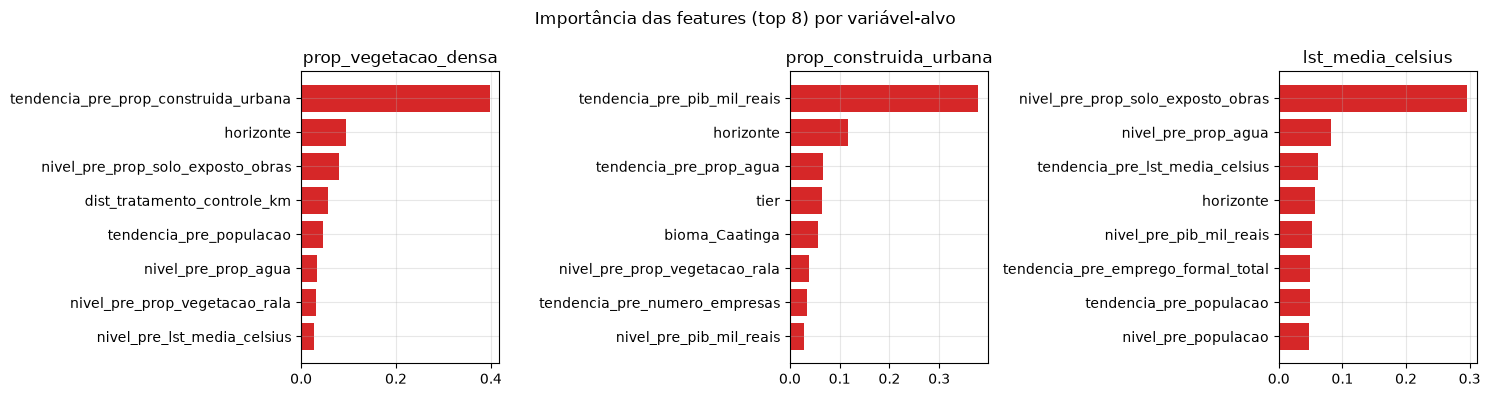

In [10]:
modelos_finais = {}
importancias = {}

for var in VARS_MODELO:
    target_col = f"efeito_liquido_{var}"
    dados_var = treino.dropna(subset=[target_col]).reset_index(drop=True)
    X = dados_var[FEATURES_NUM + FEATURES_CAT]
    y = dados_var[target_col]

    modelo = monta_modelo()
    modelo.fit(X, y)
    modelos_finais[var] = modelo

    nomes_cat = modelo.named_steps["preprocessa"].named_transformers_["cat"] \
        .named_steps["onehot"].get_feature_names_out(FEATURES_CAT)
    nomes_features = FEATURES_NUM + list(nomes_cat)
    importancias[var] = pd.Series(
        modelo.named_steps["modelo"].feature_importances_, index=nomes_features
    ).sort_values(ascending=False)

fig, axes = plt.subplots(1, len(VARS_MODELO), figsize=(15, 4))
for ax, var in zip(axes, VARS_MODELO):
    top = importancias[var].head(8).sort_values()
    ax.barh(top.index, top.values, color="tab:red")
    ax.set_title(var)
fig.suptitle("Importância das features (top 8) por variável-alvo")
fig.tight_layout()
plt.show()


## 8. Prever o impacto de um data center hipotético

In [11]:
def prever_impacto(features_dict, horizonte, variavel):
    """
    features_dict: dicionário com as chaves de FEATURES_NUM (exceto 'horizonte') e
                   FEATURES_CAT que você conseguir preencher. O que faltar é imputado
                   automaticamente (mediana / categoria "desconhecido" aprendida no treino).
    horizonte: 0, 1 ou 2 (anos desde a abertura planejada).
    variavel: uma das VARS_MODELO.
    """
    linha = {c: features_dict.get(c, np.nan) for c in FEATURES_NUM + FEATURES_CAT}
    linha["horizonte"] = horizonte
    X_novo = pd.DataFrame([linha])[FEATURES_NUM + FEATURES_CAT]
    modelo = modelos_finais[variavel]
    return modelo.predict(X_novo)[0]

# Exemplo: data center hipotético de 10 MW, 2 prédios, na Mata Atlântica
for h in [0, 1, 2]:
    valor = prever_impacto(
        {"mw_construido_total": 10, "n_predios_no_campus": 2, "bioma": "Mata Atlantica"},
        horizonte=h,
        variavel="prop_vegetacao_densa",
    )
    print(f"horizonte +{h}: efeito líquido previsto em prop_vegetacao_densa = {valor:.4f}")


horizonte +0: efeito líquido previsto em prop_vegetacao_densa = 0.0074
horizonte +1: efeito líquido previsto em prop_vegetacao_densa = 0.0076
horizonte +2: efeito líquido previsto em prop_vegetacao_densa = 0.0048


## 9. Limitações (herdadas da proposta, item 7)

- **Amostra pequena (15 pares)** — o Leave-One-DC-Out acima é a validação honesta possível hoje;
  qualquer ganho vistoso sobre a baseline de média deve ser tratado com ceticismo até a amostra
  crescer.
- **Qualidade de pareamento** — 132 das 204 linhas do painel têm `qualidade_par == "ruim"`; isso
  não foi filtrado aqui de propósito (combinado tratar isso depois), mas é a primeira alavanca a
  puxar se os resultados não melhorarem.
- **Dados de porte muito incompletos** (`mw_construido_total`, `tier`, `tier_projetado_max` têm
  entre 50% e 79% de nulos) — o `SimpleImputer` cobre o buraco tecnicamente, mas o modelo não
  aprende muito de uma coluna que é, na prática, "desconhecido" na maioria das linhas.
- **Modelo raso de propósito** (`max_depth=3`) — mantém a interpretabilidade que a proposta pede,
  mas também limita a capacidade de capturar interações mais complexas entre porte e contexto
  regional.